# Skew, convergence, and the demand/supply mechanism — a Dallas-Fed horse-race

**Motivation.** Dallas Fed economists (*"Skewness warrants caution as Trimmed Mean PCE inflation eases"*,
April 2026) show that when the cross-sectional distribution of price changes is **positively skewed**, headline
PCE converges toward **core** PCE, while the convergence coefficient on the **trimmed mean** falls to about
zero — trimming lops off a persistent right tail and becomes a downward-biased attractor.

A companion notebook (`PCE_Skew_Conditional_DemandSupply_Test.ipynb`) found, at the **component** level, that the
trim forecast error in positive-skew months is predictable from the trimmed-away **demand** and **supply** gaps.
This notebook connects the two: it (i) **reproduces** the Dallas-Fed convergence result on our data, (ii) asks
whether a *targeted* "partial un-trim" — adding the demand gap back to the trimmed mean when skew is positive —
recovers core's convergence advantage, and (iii) tests whether that targeted measure adds anything **beyond core**.

**Headline finding (preview).** The Dallas-Fed result reproduces cleanly: under positive skew at 6-12 months,
core is a strong attractor and the trim coefficient is **negative**. Our demand-augmented trim improves on plain
trim (~15% lower convergence RMSE at h=6) - but it is **dominated by, and subsumed by, core**: once core is in
the regression, the augmented measure adds nothing. The demand/supply decomposition is therefore the **economic
mechanism** behind the Dallas-Fed result, not a measure that beats core. The effect is confined to **6-12 months**;
by 24 months trim is the better attractor again.

**Conventions.** $e_M = \pi^H_{t+h}-M_t$ (forecast error of measure $M$). Convergence regression
$\Delta\pi^H_{t\to t+h}=\alpha+\lambda(M_t-\pi^H_t)+u$: $\lambda$ near 1 = full convergence to $M$.
Newey-West HAC lag $=h+11$. Skew $=$ trailing 12-month Kelly skewness (Dallas-Fed measure); 1-month Kelly skew
shown as a higher-frequency robustness gate. Revised data - this measures informational content.

In [1]:
import numpy as np, pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

# ---------------- config ----------------
DATA_FILE = "Data_Final.xlsx"; SHEET = "Sheet1"
FRED_FILE = "fred_pce_indices.csv"      # bundled FRED indices: PCEPILFE (core), PCEPI (headline)
HORIZONS  = [6, 12, 24]
SKEW12    = "Kelly_Skewness_12m_avg"    # Dallas-Fed skew measure (12-month average)
SKEW1     = "Kelly_Skewness_1m"         # higher-frequency robustness gate
def hac_lag(h): return int(h + 11)
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)

## Data

Load the decomposition file and the bundled FRED price indices, build 12-month inflation rates for **core**
(PCEPILFE) and **headline** (PCEPI), and **validate** the constructed headline against the file's `Headline_PCE`
(they must coincide). Core PCE was pulled from FRED on 2026-06-21 and bundled as `fred_pce_indices.csv` for
reproducibility (no network needed to run this notebook).

In [2]:
df = (pd.read_excel(DATA_FILE, sheet_name=SHEET, parse_dates=["Date"])
        .sort_values("Date").reset_index(drop=True))

fred = pd.read_csv(FRED_FILE, parse_dates=["observation_date"]).rename(columns={"observation_date":"Date"})
for src, out in [("PCEPILFE","Core_PCE"), ("PCEPI","Head_chk")]:
    fred[out] = 100*(fred[src]/fred[src].shift(12) - 1)        # 12-month % change
df = df.merge(fred[["Date","Core_PCE","Head_chk"]], on="Date", how="left")

# validation: constructed headline YoY must equal the file's Headline_PCE
ok = df.dropna(subset=["Head_chk"])
print(f"rows: {len(df)}   span: {df.Date.min():%Y-%m} .. {df.Date.max():%Y-%m}")
print(f"VALIDATION  corr(constructed headline, file Headline_PCE) = {ok['Headline_PCE'].corr(ok['Head_chk']):.5f}"
      f"   max|diff| = {(ok['Headline_PCE']-ok['Head_chk']).abs().max():.3f}")
ident = (df["Headline_PCE"] - df["Trimmed_Mean_PCE"]
         - df[["Demand_Gap","Supply_Gap","Ambiguous_Gap","Residual_Gap"]].sum(axis=1)).abs().max()
print(f"adding-up identity  max|error| = {ident:.2e}")
print(f"Core_PCE available for {df['Core_PCE'].notna().sum()}/{len(df)} rows")
print(f"positive 12m-skew in {100*(df[SKEW12]>0).mean():.1f}% of months | "
      f"positive 1m-skew in {100*(df[SKEW1]>0).mean():.1f}%")

rows: 545   span: 1980-12 .. 2026-04
VALIDATION  corr(constructed headline, file Headline_PCE) = 1.00000   max|diff| = 0.000
adding-up identity  max|error| = 7.17e-14
Core_PCE available for 545/545 rows
positive 12m-skew in 11.7% of months | positive 1m-skew in 29.9%


## Specification

We compare three time-$t$ gauges of where headline is heading, all known at $t$:

| Gauge | Definition |
|---|---|
| **Trim** | $\pi^{TM}_t$ |
| **Core** | 12-month core PCE inflation |
| **Trim + Demand** (ours) | $\pi^{TM}_t + \text{Demand}_t$ - parameter-free "partial un-trim" (weight = 1, nothing estimated) |

Two lenses, both restricted to **positive-skew origin months** (the regime Dallas Fed flags):

1. **Convergence RMSE** $\;\sqrt{\overline{(\pi^H_{t+h}-M_t)^2}}\;$ - how close headline lands to the gauge.
2. **Convergence horse-race** $\;\Delta\pi^H_{t\to t+h}=\alpha+\lambda_{\text{core}}(\text{core}_t-\pi^H_t)+\lambda_{\text{trim}}(\text{trim}_t-\pi^H_t)+u\;$
   - Dallas Fed predicts $\lambda_{\text{trim}}\to 0$ under positive skew. We then swap in Trim+Demand to ask
   whether it carries attractor information **beyond core**.

The "Trim+Demand" weight is **1**, so there is nothing to estimate - the in-sample number is what you could deploy.

In [3]:
def make(d0, h, SKEW):
    d = d0.copy(); d["Hf"] = d["Headline_PCE"].shift(-h)
    return d.dropna(subset=["Hf", SKEW, "Demand_Gap", "Supply_Gap", "Core_PCE"]).reset_index(drop=True)

def fit_hac(y, X, h):
    return sm.OLS(np.asarray(y, float), np.asarray(X, float)).fit(
        cov_type="HAC", cov_kwds={"maxlags": hac_lag(h), "use_correction": True})

def rmse(e):
    e = np.asarray(e, float); e = e[~np.isnan(e)]; return float(np.sqrt(np.mean(e**2)))

# gauges for a prepared frame d
def gauges(d):
    TM = d["Trimmed_Mean_PCE"].values
    return {"Trim": TM, "Core": d["Core_PCE"].values, "Trim+Demand (ours)": TM + d["Demand_Gap"].values}

## A. Convergence RMSE - who does headline land closest to under positive skew?

In [4]:
def conv_rmse(SKEW):
    rows = []
    for h in HORIZONS:
        d = make(df, h, SKEW); pos = d[SKEW].values > 0; Hf = d["Hf"].values
        G = gauges(d); base = rmse((Hf - G["Trim"])[pos])
        row = {"h": h, "n(+skew)": int(pos.sum())}
        for nm, M in G.items():
            row[f"{nm} relRMSE"] = rmse((Hf - M)[pos]) / base
        rows.append(row)
    return pd.DataFrame(rows).set_index("h").round(3)

print("Gate = 12-month-avg Kelly skew>0  (Dallas-Fed measure)  | relRMSE vs Trim, positive-skew origins")
display(conv_rmse(SKEW12))
print("\nGate = 1-month Kelly skew>0  (robustness)")
display(conv_rmse(SKEW1))

Gate = 12-month-avg Kelly skew>0  (Dallas-Fed measure)  | relRMSE vs Trim, positive-skew origins


,n(+skew),Trim relRMSE,Core relRMSE,Trim+Demand (ours) relRMSE
h,,,,
6,59,1.0,0.727,0.847
12,59,1.0,0.856,0.990
24,59,1.0,1.170,1.273



Gate = 1-month Kelly skew>0  (robustness)


,n(+skew),Trim relRMSE,Core relRMSE,Trim+Demand (ours) relRMSE
h,,,,
6,157,1.0,0.858,0.898
12,153,1.0,0.947,1.030
24,149,1.0,1.125,1.162


**Core wins decisively under positive skew.** At $h=6$ core's convergence RMSE is ~27% below trim
(relRMSE $\approx0.73$) and at $h=12$ ~14% below. Our **Trim+Demand** measure moves in the right direction -
~15% better than trim at $h=6$ - but stops well short of core. By $h=24$ both core and the augmentation are
*worse* than plain trim: the positive-skew bias is a 6-12-month phenomenon that self-corrects by two years.

## B. The Dallas-Fed convergence horse-race

$\Delta\pi^H = \alpha + \lambda_{\text{core}}(\text{core}-\pi^H) + \lambda_{\text{trim}}(\text{trim}-\pi^H)$,
positive-skew origins. Dallas Fed: the **trim** coefficient collapses toward zero.

In [5]:
def horserace(SKEW):
    rows = []
    for h in HORIZONS:
        d = make(df, h, SKEW); pos = d[SKEW].values > 0
        H = d["Headline_PCE"].values; y = (d["Hf"].values - H)[pos]
        g_co = (d["Core_PCE"].values - H)[pos]; g_tm = (d["Trimmed_Mean_PCE"].values - H)[pos]
        m = fit_hac(y, sm.add_constant(np.column_stack([g_co, g_tm])), h)
        rows.append({"h": h, "n(+skew)": int(pos.sum()),
                     "lambda_core": m.params[1], "t_core": m.tvalues[1],
                     "lambda_trim": m.params[2], "t_trim": m.tvalues[2]})
    return pd.DataFrame(rows).set_index("h").round(3)

print("Gate = 12-month-avg Kelly skew>0  (Dallas-Fed measure)")
display(horserace(SKEW12))
print("\nGate = 1-month Kelly skew>0  (robustness)")
display(horserace(SKEW1))

Gate = 12-month-avg Kelly skew>0  (Dallas-Fed measure)


,n(+skew),lambda_core,t_core,lambda_trim,t_trim
h,,,,,
6,59,2.593,5.442,-0.768,-2.404
12,59,4.742,9.022,-0.963,-3.932
24,59,1.707,2.284,1.057,2.436



Gate = 1-month Kelly skew>0  (robustness)


,n(+skew),lambda_core,t_core,lambda_trim,t_trim
h,,,,,
6,157,0.517,0.879,-0.030,-0.065
12,153,1.132,1.272,0.035,0.057
24,149,-0.095,-0.167,1.433,3.186


**Reproduced - and stronger.** Under positive skew at $h=6,12$, $\lambda_{\text{core}}$ is large and highly
significant while $\lambda_{\text{trim}}$ is **negative and significant** (not merely $\approx0$): conditioning on
positive skew, the trimmed mean is a *perverse* attractor - headline moves away from it, toward core. At $h=24$
the sign flips and trim reasserts ($\lambda_{\text{trim}}>0$, significant), confirming the bias is medium-horizon.

## C. Does our targeted "Trim + Demand" add anything **beyond** core?

Replace trim with the demand-augmented measure and run it head-to-head with core. If the augmentation captured
something core misses, its coefficient would survive next to core.

In [6]:
def beyond_core(SKEW):
    rows = []
    for h in HORIZONS:
        d = make(df, h, SKEW); pos = d[SKEW].values > 0
        H = d["Headline_PCE"].values; y = (d["Hf"].values - H)[pos]
        g_co = (d["Core_PCE"].values - H)[pos]
        g_au = ((d["Trimmed_Mean_PCE"].values + d["Demand_Gap"].values) - H)[pos]
        m = fit_hac(y, sm.add_constant(np.column_stack([g_co, g_au])), h)
        rows.append({"h": h, "lambda_core": m.params[1], "t_core": m.tvalues[1],
                     "lambda_TrimDem": m.params[2], "t_TrimDem": m.tvalues[2]})
    return pd.DataFrame(rows).set_index("h").round(3)

print("core  vs  Trim+Demand   (gate = 12-month-avg Kelly skew>0)")
display(beyond_core(SKEW12))

core  vs  Trim+Demand   (gate = 12-month-avg Kelly skew>0)


,lambda_core,t_core,lambda_TrimDem,t_TrimDem
h,,,,
6,2.556,5.172,-1.056,-1.189
12,4.790,9.858,-1.512,-1.570
24,2.345,2.131,0.283,0.390


**No.** With core in the regression, the Trim+Demand coefficient is **insignificant** (|t| ~ 1.2-1.6) and
even negative. The demand gap is a noisy *partial* proxy for what core retains and trim discards; core keeps the
whole distribution (food, energy, both tails) and statistically subsumes the targeted measure. The decomposition's
value here is **explanatory**, not a forecast that beats core.

## D. Figure

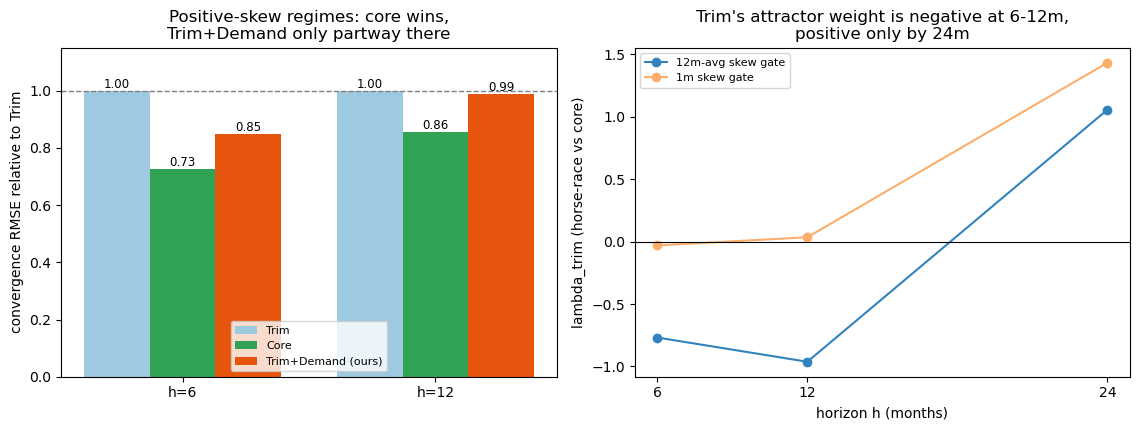

In [7]:
SKEW = SKEW12
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

# left: relRMSE bars, positive-skew origins, h=6 and h=12
ax = axes[0]; hs = [6, 12]; names = ["Trim", "Core", "Trim+Demand (ours)"]
cols = {"Trim": "#9ecae1", "Core": "#31a354", "Trim+Demand (ours)": "#e6550d"}
width = 0.26; x = np.arange(len(hs))
for j, nm in enumerate(names):
    vals = []
    for h in hs:
        d = make(df, h, SKEW); pos = d[SKEW].values > 0; Hf = d["Hf"].values; G = gauges(d)
        vals.append(rmse((Hf - G[nm])[pos]) / rmse((Hf - G["Trim"])[pos]))
    b = ax.bar(x + (j-1)*width, vals, width, label=nm, color=cols[nm])
    for bb, v in zip(b, vals): ax.text(bb.get_x()+bb.get_width()/2, v+0.01, f"{v:.2f}", ha="center", fontsize=8.5)
ax.axhline(1.0, ls="--", color="grey", lw=1)
ax.set_xticks(x); ax.set_xticklabels([f"h={h}" for h in hs])
ax.set_ylabel("convergence RMSE relative to Trim"); ax.set_ylim(0, 1.15)
ax.set_title("Positive-skew regimes: core wins,\nTrim+Demand only partway there"); ax.legend(fontsize=8)

# right: lambda_trim across horizons (the Dallas-Fed collapse), both gates
ax = axes[1]
for SK, c, lab in [(SKEW12, "#3182bd", "12m-avg skew gate"), (SKEW1, "#fdae6b", "1m skew gate")]:
    lt = []
    for h in HORIZONS:
        d = make(df, h, SK); pos = d[SK].values > 0; H = d["Headline_PCE"].values
        y = (d["Hf"].values - H)[pos]
        g_co = (d["Core_PCE"].values - H)[pos]; g_tm = (d["Trimmed_Mean_PCE"].values - H)[pos]
        m = fit_hac(y, sm.add_constant(np.column_stack([g_co, g_tm])), h); lt.append(m.params[2])
    ax.plot(HORIZONS, lt, "o-", color=c, label=lab)
ax.axhline(0, color="k", lw=.8)
ax.set_xlabel("horizon h (months)"); ax.set_ylabel("lambda_trim (horse-race vs core)")
ax.set_title("Trim's attractor weight is negative at 6-12m,\npositive only by 24m"); ax.set_xticks(HORIZONS)
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUT/"fig_convergence.png", dpi=120, bbox_inches="tight"); plt.show()

## Conclusion

**Can the demand/supply factors augment the trimmed mean to converge better when skew is positive?**

1. **The Dallas-Fed result holds in our data.** Under positive skew at 6-12 months, headline converges to **core**,
   and the trimmed mean's convergence weight is **negative** - trimming discards a persistent right tail and becomes
   a downward-biased attractor. (Self-corrects by 24 months.)

2. **Our decomposition is the mechanism.** The same trimmed-away **demand/supply** signal that predicts the trim
   error (companion notebook) is what makes core the better gauge: a demand-augmented "partial un-trim" recovers
   ~15% of trim's positive-skew RMSE gap at $h=6$.

3. **But the targeted measure does not beat core, and is subsumed by it.** Once core is in the convergence
   regression, Trim+Demand adds nothing (|t| ~ 1.2-1.6). The demand gap is a noisy partial proxy for what core
   keeps wholesale.

**Practical implication.** The deployable response to positive skew is the simple one: **lean toward core** (or a
core/trim blend) rather than engineer a demand-augmented trim. The contribution of the demand/supply decomposition
is to **explain why** trim fails in these regimes - it pinpoints the economic content (demand- and supply-driven
tail inflation) of what trimming throws away - which is exactly the caution the Dallas-Fed note raises for the
current, supply-disruption-prone environment.